# BayesianNetwork

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score,classification_report
import io

In [ ]:
!pip install pgmpy

In [ ]:
df = pd.read_csv('mentalHdataset.csv')
df.isnull().sum()
df = df.dropna()
df = df.drop(['Timestamp', 'Age', 'state','Unnamed: 0','comments'] ,axis=1)
df['Gender'] = df['Gender'].replace(['Male', 'Female', 'Other'], [0, 1, 2])
df = df.replace(('No','Yes','Maybe','Some of them', 'Don\'t know','Not sure'), (0,1,2,2,2,2))
df['Country'] = df['Country'].replace(['United States', 'Israel'], [0, 1])
df['work_interfere'] = df['work_interfere'].replace(['Rarely', 'Sometimes', 'Often', 'Never'], [0, 1, 2, 3])
df['leave'] = df['leave'].replace(['Very easy', 'Somewhat easy', 'Somewhat difficult','Very difficult'], [0, 1, 2, 3])
df['no_employees'] = df['no_employees'].replace(['26-100', 'More than 1000', '01-May', 'Jun-25', '500-1000','100-500'], [26, 1000, 0, 0, 500, 100])
df['Age_cat'] = df['Age_cat'].replace(['(31, 72]', '(18, 31]'], [31, 18])
df.head()

,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Age_cat
24,0,0,0,1,1,0,26,0,1,1,...,2,0,0,1,1,0,1,2,0,31
25,0,0,0,1,1,1,1000,0,0,1,...,0,1,0,2,1,0,1,0,0,31
33,0,0,0,1,1,1,26,1,1,1,...,0,2,0,2,2,2,1,2,0,31
45,1,0,0,1,1,1,26,0,1,1,...,1,0,0,2,1,0,0,1,0,31
49,0,0,0,1,1,0,26,0,1,1,...,2,2,0,2,1,0,0,2,0,18


In [ ]:
x_vars = df.drop(['treatment','self_employed', 'no_employees','remote_work','benefits','seek_help','leave','mental_health_consequence', 'supervisor', 'mental_health_interview', 'obs_consequence' ] ,axis=1)
y_vars = df['treatment']
x_vars.dtypes

Gender                     int64
Country                    int64
family_history             int64
work_interfere             int64
tech_company               int64
care_options               int64
wellness_program           int64
anonymity                  int64
phys_health_consequence    int64
coworkers                  int64
phys_health_interview      int64
mental_vs_physical         int64
Age_cat                    int64
dtype: object

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_vars,y_vars, train_size = 0.7,random_state=42)
data = x_train.join(y_train)
print(data.shape)

(58, 14)


In [ ]:
from pgmpy.estimators import BDeuScore, K2Score, BicScore
from pgmpy.models import BayesianModel

In [ ]:
#Calculating scores
bdeu = BDeuScore(data, equivalent_sample_size=13)
k2 = K2Score(data)
bic = BicScore(data)

In [ ]:
from pgmpy.estimators import HillClimbSearch

hc = HillClimbSearch(data)
best_model = hc.estimate(scoring_method=bdeu)
print(sorted(best_model.nodes()))
print(best_model.edges())

  0%|          | 0/1000000 [00:00<?, ?it/s]

['Age_cat', 'Country', 'Gender', 'anonymity', 'care_options', 'coworkers', 'family_history', 'mental_vs_physical', 'phys_health_consequence', 'phys_health_interview', 'tech_company', 'treatment', 'wellness_program', 'work_interfere']
[('family_history', 'mental_vs_physical'), ('work_interfere', 'treatment'), ('tech_company', 'care_options'), ('care_options', 'treatment'), ('anonymity', 'care_options'), ('anonymity', 'mental_vs_physical'), ('anonymity', 'wellness_program'), ('anonymity', 'tech_company'), ('anonymity', 'Gender'), ('phys_health_consequence', 'coworkers'), ('phys_health_consequence', 'treatment'), ('coworkers', 'anonymity'), ('coworkers', 'Age_cat'), ('phys_health_interview', 'work_interfere'), ('phys_health_interview', 'care_options'), ('treatment', 'family_history'), ('treatment', 'wellness_program')]


In [ ]:
from pgmpy.models import BayesianNetwork
model_final = BayesianNetwork(best_model)

In [ ]:
from pgmpy.estimators import BayesianEstimator
model_final.fit(data, estimator=BayesianEstimator, prior_type="BDeu", equivalent_sample_size=13)
for cpd in model_final.get_cpds():
    print(cpd)

+-----------+---------------------+---------------------+---------------------+
| anonymity | anonymity(0)        | anonymity(1)        | anonymity(2)        |
+-----------+---------------------+---------------------+---------------------+
| Gender(0) | 0.46969696969696967 | 0.5864978902953586  | 0.6815476190476191  |
+-----------+---------------------+---------------------+---------------------+
| Gender(1) | 0.19696969696969696 | 0.28270042194092826 | 0.2797619047619048  |
+-----------+---------------------+---------------------+---------------------+
| Gender(2) | 0.3333333333333333  | 0.13080168776371306 | 0.03869047619047619 |
+-----------+---------------------+---------------------+---------------------+
+------------+---+
| Country(0) | 1 |
+------------+---+
+-------------------+---------------------+---------------------+
| treatment         | treatment(0)        | treatment(1)        |
+-------------------+---------------------+---------------------+
| family_history(0) | 0.7

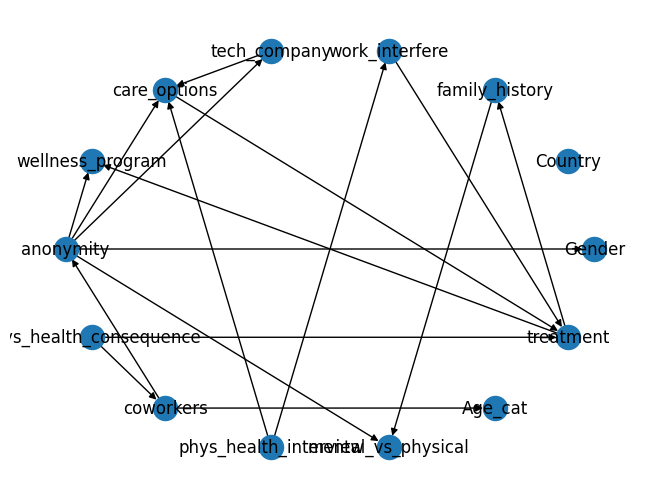

In [ ]:
import networkx as nx
import pylab as plt
pos = nx.circular_layout(model_final)
nx.draw(model_final,pos = pos, with_labels=True)

In [ ]:
# Infering the posterior probability
from pgmpy.inference import VariableElimination
from pandas.core.groupby.groupby import DataFrame
infer = VariableElimination(model_final)
num_rows, num_cols = x_test.shape
print(num_rows)
posterior_py = np.empty(shape=(num_rows,2))
print(posterior_py.shape)
print(x_test.columns)

26
(26, 2)
Index(['Gender', 'Country', 'family_history', 'work_interfere', 'tech_company',
       'care_options', 'wellness_program', 'anonymity',
       'phys_health_consequence', 'coworkers', 'phys_health_interview',
       'mental_vs_physical', 'Age_cat'],
      dtype='object')


In [ ]:
result = infer.query(['treatment'], evidence={'work_interfere': x_test.iat[0,4]})
print(result)

+--------------+------------------+
| treatment    |   phi(treatment) |
+==============+==================+
| treatment(0) |           0.1457 |
+--------------+------------------+
| treatment(1) |           0.8543 |
+--------------+------------------+


In [ ]:
 for i in range(num_rows):
  try:
    print('Gender',x_test.iat[i,0], 'Country',x_test.iat[i,1], 'family_history',x_test.iat[i,2], 'work_interfere',x_test.iat[i,4],
       'tech_company',x_test.iat[i,4], 'care_options',x_test.iat[i,5], 'wellness_program',x_test.iat[i,6], 'anonymity',x_test.iat[i,7],
       'phys_health_consequence',x_test.iat[i,8], 'coworkers',x_test.iat[i,9], 'phys_health_interview',x_test.iat[i,10],
       'mental_vs_physical',x_test.iat[i,11],'Age_cat',x_test.iat[i,12])
    result = infer.query(['treatment'], evidence={'work_interfere': x_test.iat[i,3]})
    posterior_py[i]= result.values[0],result.values[1]
  except KeyError as exception:
      print('KeyError: {} does not exist in the column {}.'.format(str(exception),i))
      continue

Gender 1 Country 0 family_history 1 work_interfere 1 tech_company 1 care_options 1 wellness_program 0 anonymity 2 phys_health_consequence 2 coworkers 0 phys_health_interview 2 mental_vs_physical 2 Age_cat 31
Gender 0 Country 0 family_history 1 work_interfere 1 tech_company 1 care_options 2 wellness_program 2 anonymity 1 phys_health_consequence 0 coworkers 1 phys_health_interview 1 mental_vs_physical 2 Age_cat 31
Gender 0 Country 0 family_history 0 work_interfere 1 tech_company 1 care_options 1 wellness_program 0 anonymity 1 phys_health_consequence 0 coworkers 2 phys_health_interview 2 mental_vs_physical 1 Age_cat 31
Gender 0 Country 0 family_history 1 work_interfere 1 tech_company 1 care_options 1 wellness_program 1 anonymity 1 phys_health_consequence 0 coworkers 1 phys_health_interview 0 mental_vs_physical 1 Age_cat 31
Gender 1 Country 0 family_history 1 work_interfere 1 tech_company 1 care_options 0 wellness_program 2 anonymity 2 phys_health_consequence 0 coworkers 2 phys_health_inte

In [ ]:
print(posterior_py)

[[0.14572648 0.85427352]
 [0.44375437 0.55624563]
 [0.75326227 0.24673773]
 [0.44375437 0.55624563]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.44375437 0.55624563]
 [0.44375437 0.55624563]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.75326227 0.24673773]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.14572648 0.85427352]
 [0.44375437 0.55624563]
 [0.14572648 0.85427352]
 [0.3405385  0.6594615 ]
 [0.14572648 0.85427352]]


In [ ]:
y_pred=list()
for i in range(num_rows):
  if posterior_py[i][0]>posterior_py[i][1]:
    y_pred.append(0)
  else:
    y_pred.append(1)

In [ ]:
ypred = pd.core.series.Series(y_pred)
print(ypred)

0     1
1     1
2     0
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    0
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
dtype: int64


In [ ]:
import sklearn.metrics
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.88      1.00      0.93        21

    accuracy                           0.88        26
   macro avg       0.94      0.70      0.75        26
weighted avg       0.90      0.88      0.86        26



In [ ]:
pd.crosstab(y_test, y_pred, rownames = ["Actual"],colnames = ["Predicted"])

Predicted,0,1
Actual,,
0,2,3
1,0,21


In [ ]:
print(round(accuracy_score(y_test, ypred, normalize=True, sample_weight=None),4))

0.8846
